# Import Libraries

In [ ]:
from time import time
import scipy.cluster.hierarchy as spc
from pennylane import numpy as pnp
import pennylane as qml
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# set style matplotlib
sns.set_style("whitegrid")

# Data Import

### Creating column names based on the readme file

In [ ]:
operational_settings = ['op_setting_{}'.format(i + 1) for i in range(3)]
sensor_columns = ['sensor_{}'.format(i + 1) for i in range(27)]
features = operational_settings + sensor_columns
metadata = ['engine_no', 'time_in_cycles']
list_columns = metadata + features

 ### Importing training data and adding headers to the table

In [ ]:
df = pd.read_csv('./CMAPSSData/train_FD001.txt', sep=' ',
                 header=None, names=list_columns)
df.head(2)

,engine_no,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388,100.0,39.06,23.4190,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388,100.0,39.00,23.4236,NaN,NaN,NaN,NaN,NaN,NaN


# Data preprocessing

### Adding RUL column and reorganizing the df

In [ ]:
df_max_life = df.groupby('engine_no')['time_in_cycles'].max().reset_index()
df_max_life.rename(columns={'time_in_cycles': 'Max Life'}, inplace=True)
df = df.merge(df_max_life, on=['engine_no'], how='left')
df['RUL'] = df['Max Life'] - df['time_in_cycles']

df

,engine_no,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,Max Life,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,39.06,23.4190,NaN,NaN,NaN,NaN,NaN,NaN,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,39.00,23.4236,NaN,NaN,NaN,NaN,NaN,NaN,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,38.95,23.3442,NaN,NaN,NaN,NaN,NaN,NaN,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,38.88,23.3739,NaN,NaN,NaN,NaN,NaN,NaN,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,38.90,23.4044,NaN,NaN,NaN,NaN,NaN,NaN,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,38.49,22.9735,NaN,NaN,NaN,NaN,NaN,NaN,200,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,38.30,23.1594,NaN,NaN,NaN,NaN,NaN,NaN,200,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,38.44,22.9333,NaN,NaN,NaN,NaN,NaN,NaN,200,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,38.29,23.0640,NaN,NaN,NaN,NaN,NaN,NaN,200,1


### Deleting NaN and constant columns

In [ ]:
for col in df.columns:
    if len(df[col].unique()) == 1:
        df.drop(col, inplace=True, axis=1)

### Using Pearson correlation matrix choosing top 4 most correlated indicators

### Deleting irrelevant data from training set

```python 
df.drop(['op_setting_1', 'op_setting_2', 'engine_no', 'time_in_cycles'],inplace=True,axis=1)

## Normalize data

In [ ]:
for col in df.columns:
    if col != 'engine_no':
        df[col] = (df[col]-df[col].min())/(df[col].max() - df[col].min())

# Correlation analysis

### Pearson Matrix

In [ ]:
pearson = df.copy()
pearson.drop(['engine_no', 'time_in_cycles', 'Max Life'], axis=1, inplace=True)
pearson = pearson.corr(method='pearson')

### Define cutoff

In [ ]:
max_distance = 0.1

### Dendrogram

In [189]:
def fancy_dendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = spc.dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

### Pearson Heatmap

Text(0.5, 1.0, 'Pearson Correlation Heatmap')

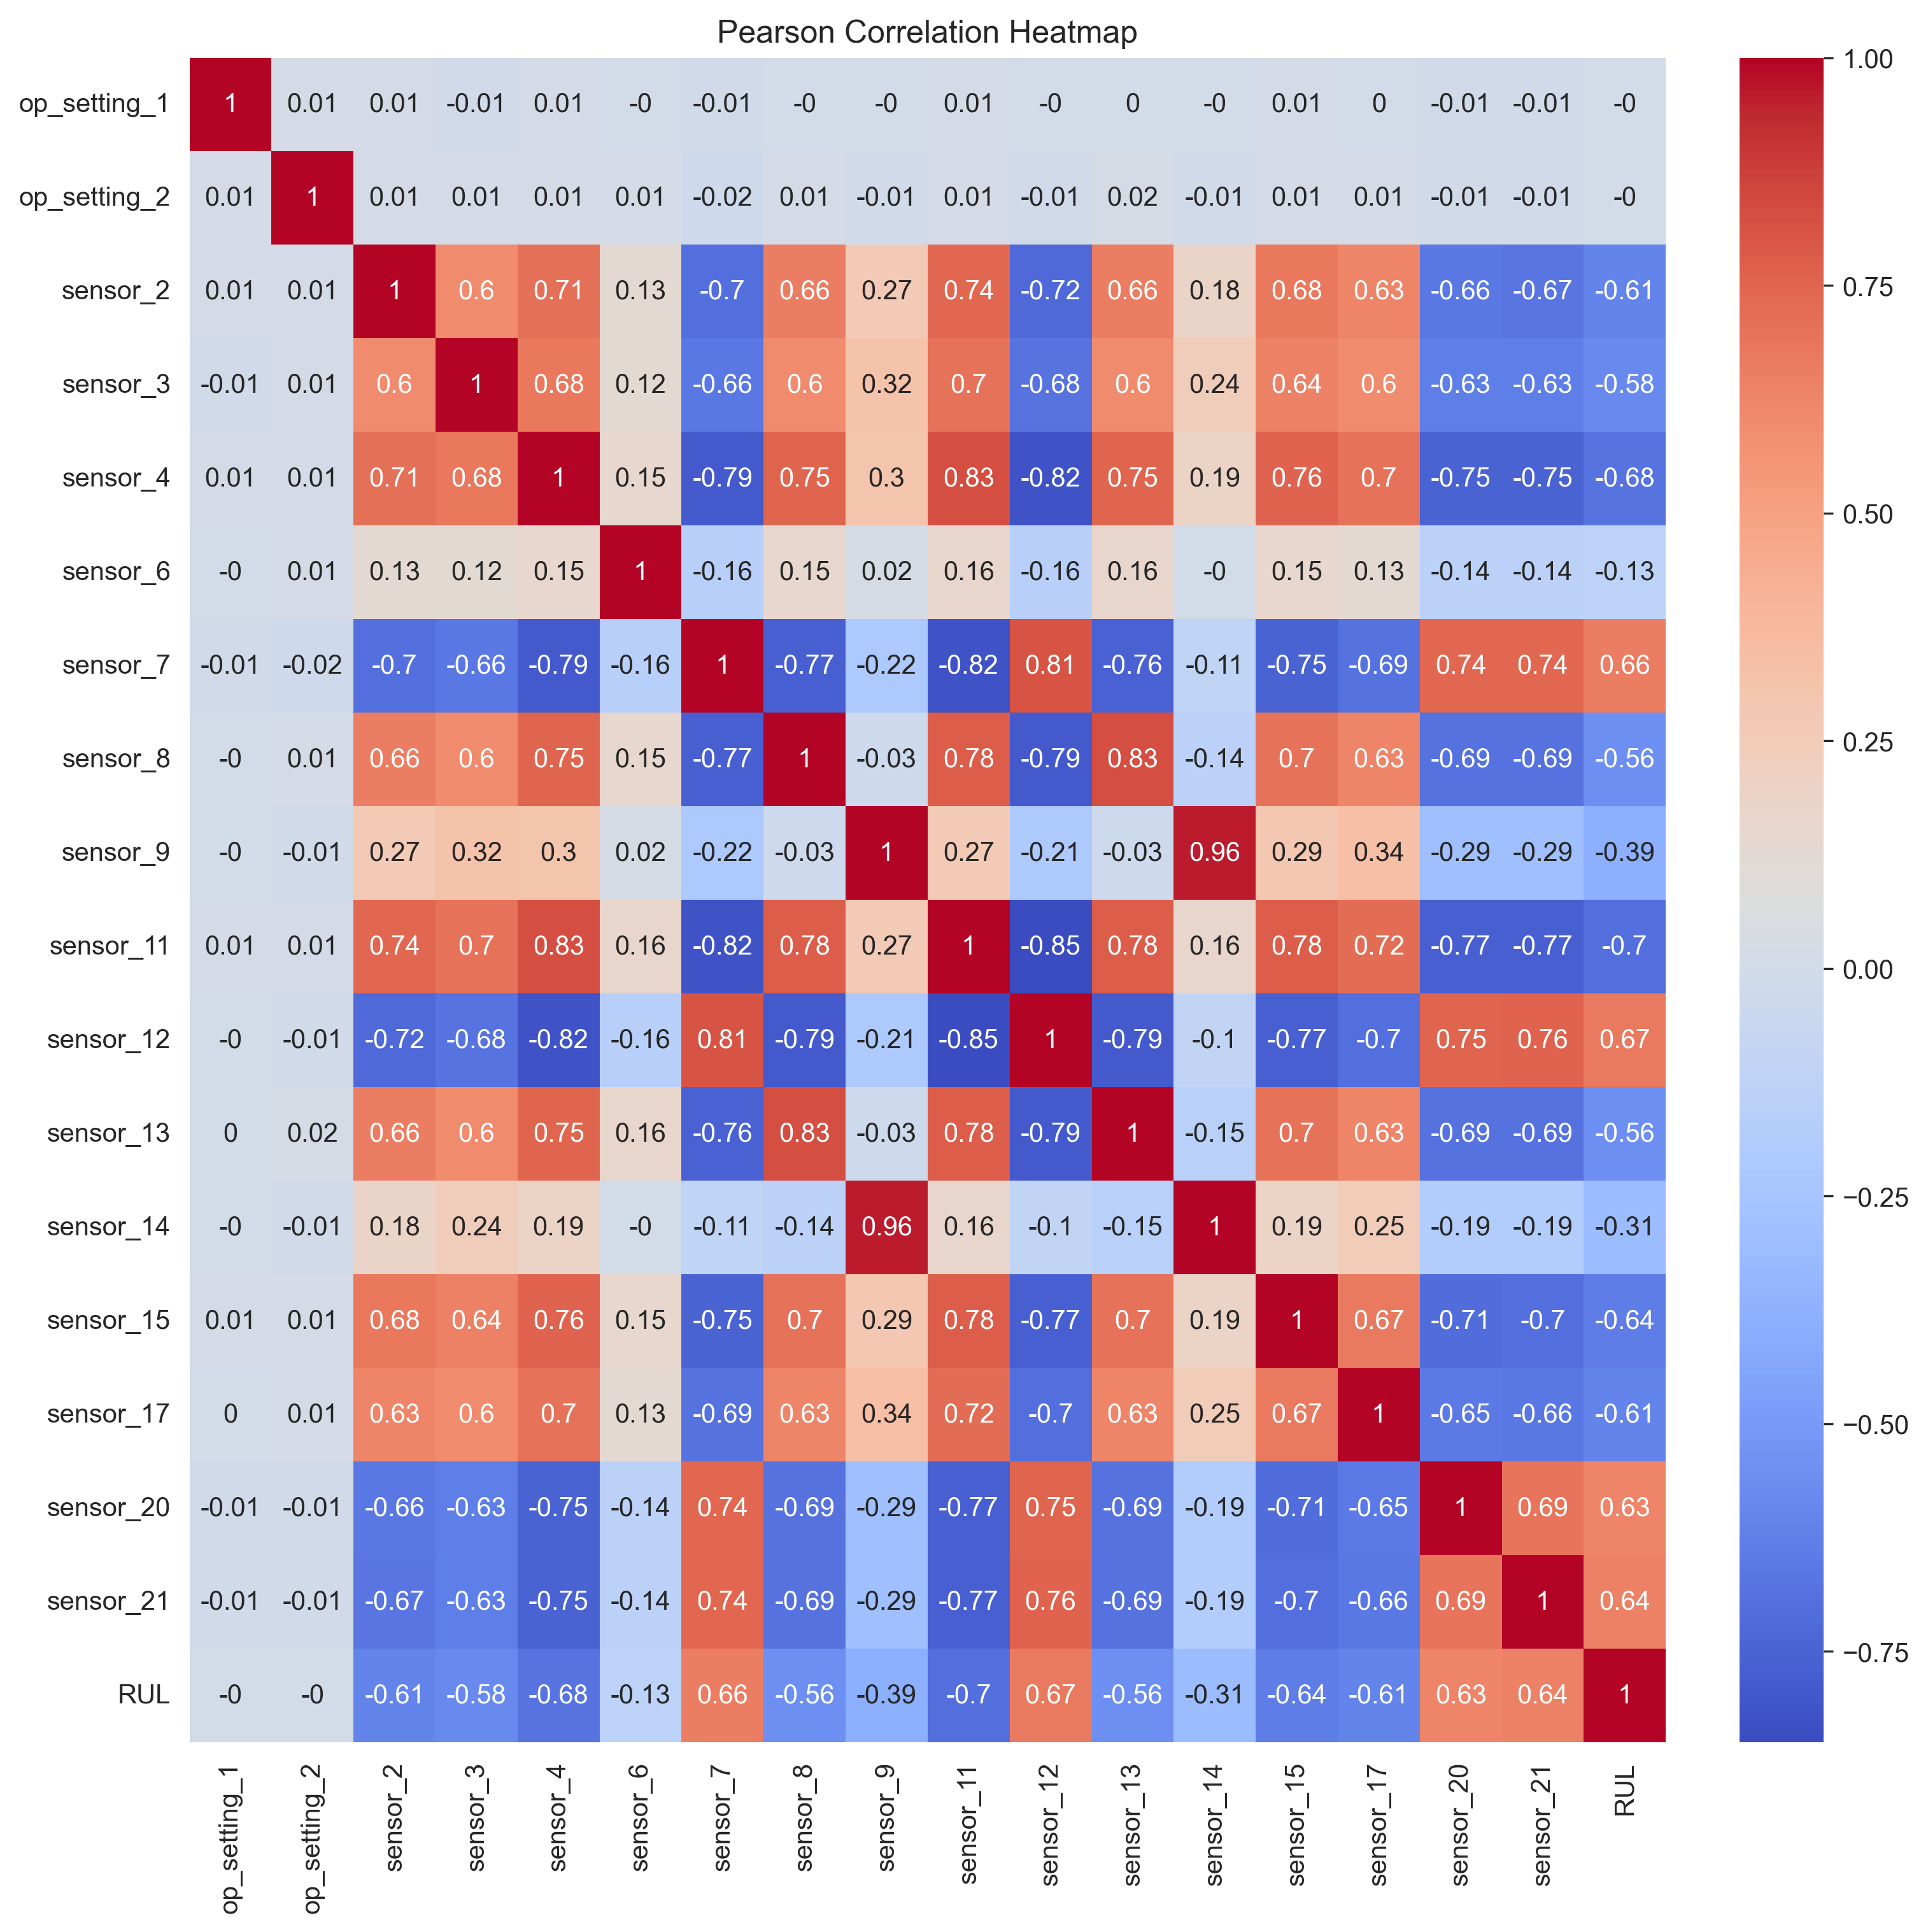

In [ ]:
fig, axes = plt.subplots(figsize=(10, 10), layout='constrained',
                         dpi=300
                         )
sns.heatmap(pearson.round(2), annot=True, cmap='coolwarm', fmt='.2g', ax=axes)
axes.set_title('Pearson Correlation Heatmap')

,Feature,Correlation
0,RUL,1.000000
1,sensor_11,0.696228
2,sensor_4,0.678948
3,sensor_12,0.671983
4,sensor_7,0.657223
5,sensor_15,0.642667
6,sensor_21,0.635662
7,sensor_20,0.629428
8,sensor_2,0.606484
9,sensor_17,0.606154


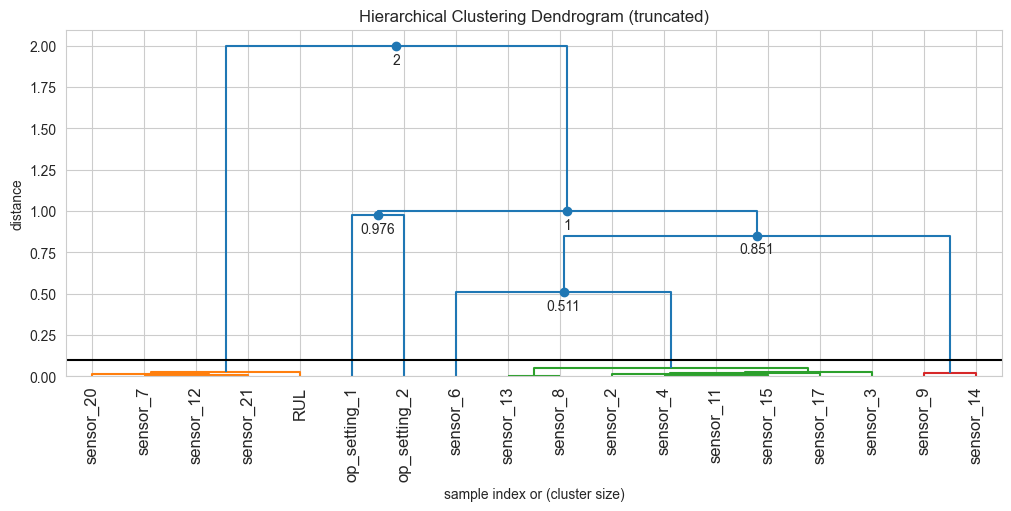

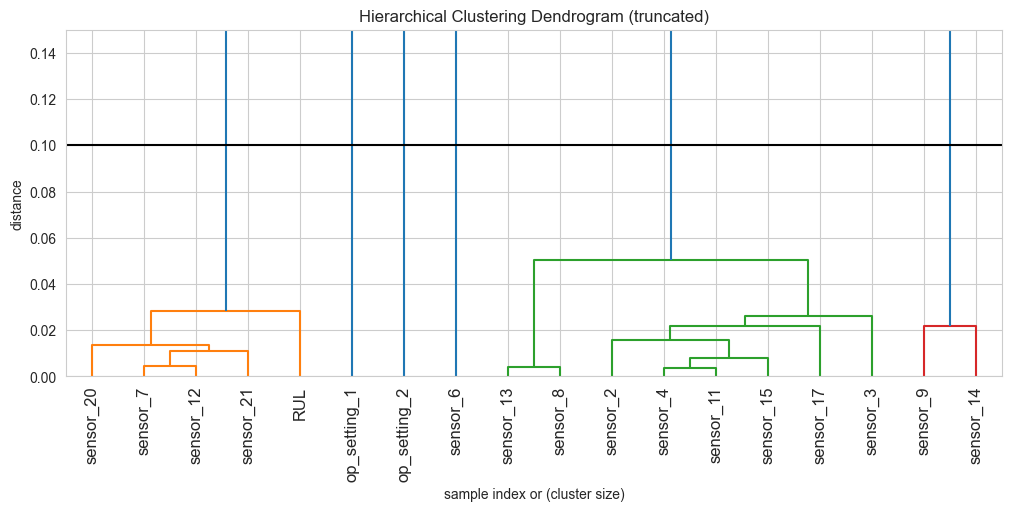

In [ ]:
linkage_corr = spc.linkage(pearson, method='complete',
                           metric='cosine', optimal_ordering=True)

fig, axes = plt.subplots(figsize=(10, 5), layout='constrained',
                         # dpi=150
                         )
tree = fancy_dendrogram(linkage_corr,
                        # orientation='left',
                        p=100,
                        labels=pearson.columns.tolist(),
                        show_leaf_counts=True,
                        show_contracted=True,
                        leaf_rotation=90,
                        max_d=max_distance,
                        annotate_above=0.09,
                        ax=axes)

fig, axes = plt.subplots(figsize=(10, 5), layout='constrained',
                         # dpi=150
                         )
tree = fancy_dendrogram(linkage_corr,
                        # orientation='left',
                        p=100,
                        labels=pearson.columns.tolist(),
                        show_leaf_counts=True,
                        show_contracted=True,
                        leaf_rotation=90,
                        max_d=max_distance,
                        annotate_above=0.09,
                        ax=axes)

axes.set_ylim(0, max_distance + 0.05)

RUL_corr = pearson.abs().sort_values('RUL', ascending=False)['RUL'].reset_index(
    drop=False).rename(columns={'RUL': 'Correlation', 'index': 'Feature'})
RUL_corr

### Clusters

In [192]:
clusters = spc.fcluster(linkage_corr, t=max_distance, criterion='distance')

clustered_features = {}
for feature, cluster_id in zip(pearson.columns, clusters):
    clustered_features.setdefault(cluster_id, []).append(feature)

clustered_features

{2: ['op_setting_1'],
 3: ['op_setting_2'],
 4: ['sensor_2',
  'sensor_3',
  'sensor_4',
  'sensor_8',
  'sensor_11',
  'sensor_13',
  'sensor_15',
  'sensor_17'],
 5: ['sensor_6'],
 1: ['sensor_7', 'sensor_12', 'sensor_20', 'sensor_21', 'RUL'],
 6: ['sensor_9', 'sensor_14']}

In [ ]:
selected_features = []
for cluster_id, features in clustered_features.items():
    features = [x for x in features if x != 'RUL']
    if features:
        # Select the feature from this cluster with the highest correlation to RUL
        feature = RUL_corr[RUL_corr['Feature'].isin(features)].sort_values(
            'Correlation', ascending=False)['Feature'].iloc[0]
        selected_features.append(feature)

selected_features

['op_setting_1',
 'op_setting_2',
 'sensor_11',
 'sensor_6',
 'sensor_12',
 'sensor_9']

# Neural Network

## Creating the neural network model

In [ ]:
df = df[selected_features]
df.shape

(20631, 6)

In [ ]:
# repeatedly reduce the size
class Autoencoder_Linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(6, 4),
            nn.ReLU(),
            nn.Linear(4, 3),
            nn.ReLU(),
            nn.Linear(3, 2),

        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 4),
            nn.ReLU(),
            nn.Linear(4, 6),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
model = Autoencoder_Linear()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3,
                             weight_decay=1e-5)

## Transform df to tensor

In [197]:
X = torch.tensor(df.values, dtype=torch.float32)

## Train model and calculate losses

In [ ]:
num_epochs = 1000
outputs = []
loss_dict = {}
start_neural_time = time()
for epoch in tqdm(range(num_epochs)):
    recon = model(X)
    loss = criterion(recon, X)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_dict[epoch] = loss.item()

    # if in the last 10 epochs the loss is not decreasing by at least 1e-3, break
    if epoch > num_epochs - 10:
        break_flag = np.std(list(loss_dict.values())[-10:])
        if break_flag < 1e-3:
            print(f"Early stopping at epoch {epoch}")
            break

end_neural_time = time() - start_neural_time
print(f"Neural network training time: {end_neural_time:.2f} seconds")

 99%|█████████▉| 991/1000 [00:05<00:00, 195.57it/s]

Early stopping at epoch 991
Neural network training time: 5.07 seconds


<Axes: xlabel='Epoch', ylabel='Loss'>

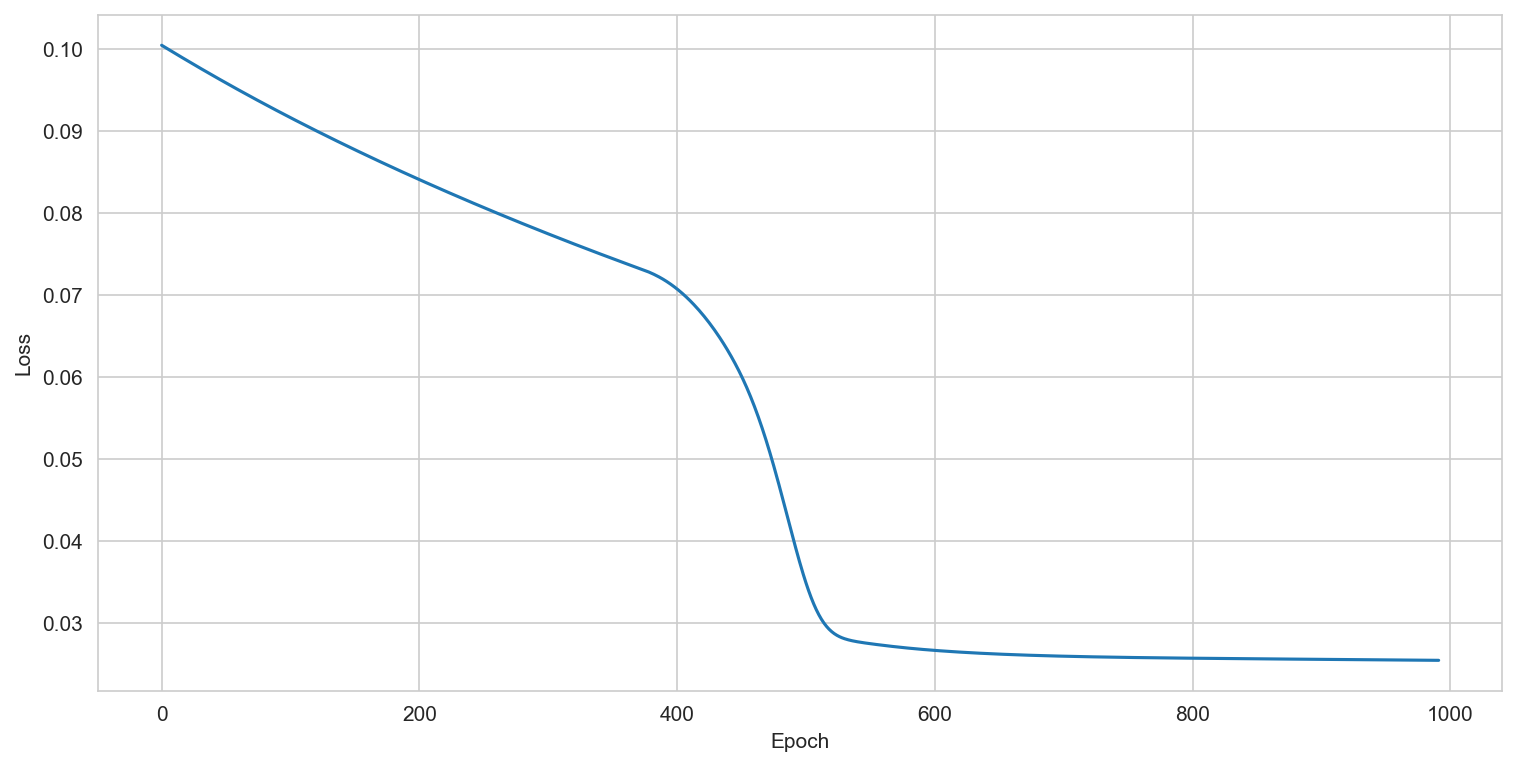

In [ ]:
df_loss = pd.DataFrame.from_dict(loss_dict, orient='index', columns=['Loss'])

fig, ax = plt.subplots(figsize=(10, 5), layout='constrained', dpi=150)
df_loss.index.name = 'Epoch'
df_loss.reset_index(inplace=True)
df_loss['Model'] = 'Neural Network'
sns.lineplot(data=df_loss, x='Epoch', y='Loss', ax=ax)

## Compare original and reconstructed signal

### Single row

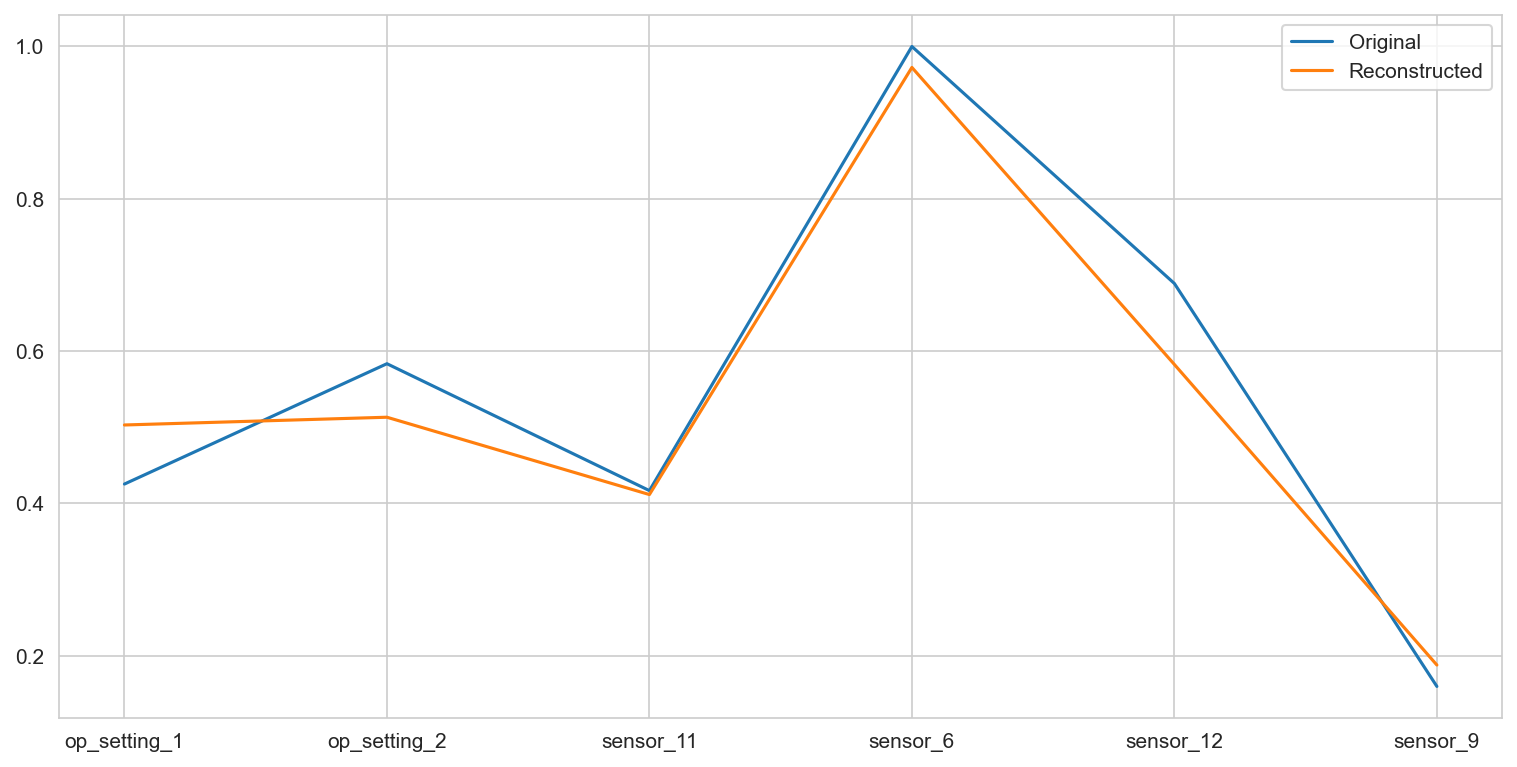

In [ ]:
i = np.random.randint(0, len(X))
original = X[i].detach().numpy()
reconstructed = model(X[i].unsqueeze(0)).detach().numpy()[0]

fig, axes = plt.subplots(figsize=(10, 5), layout='constrained', dpi=150)

axes.plot(selected_features, original, label='Original')
axes.plot(selected_features, reconstructed, label='Reconstructed')
axes.legend()

### All rows

<Axes: xlabel='sensor', ylabel='delta'>

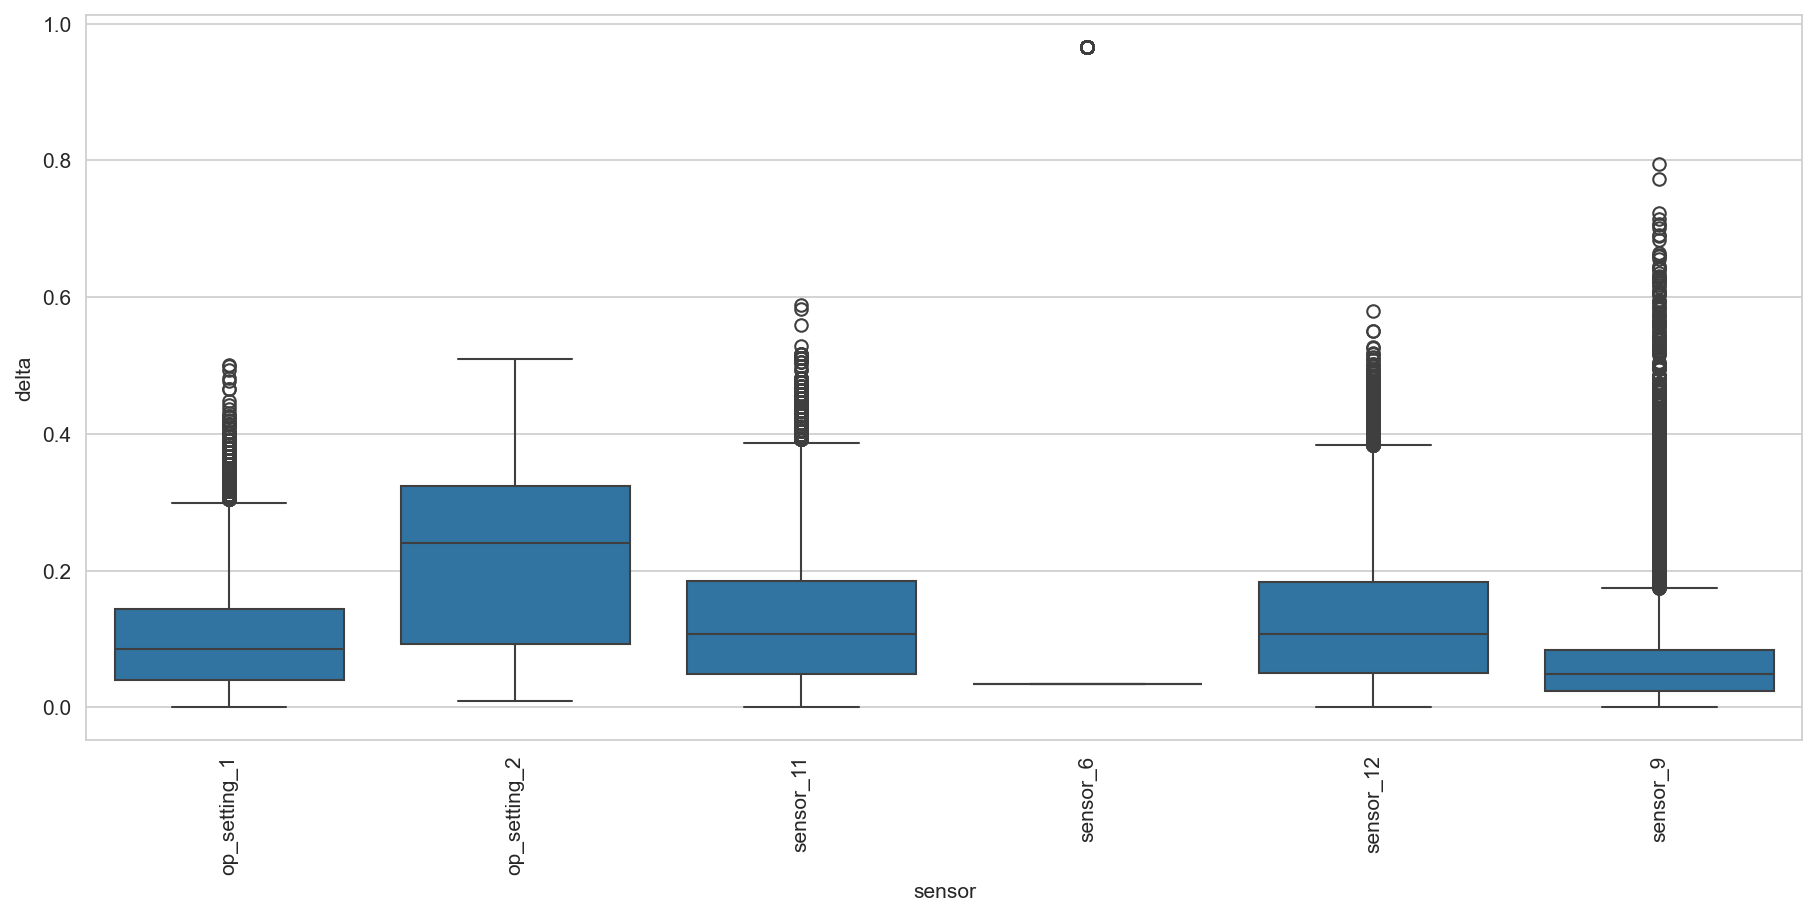

In [ ]:
original = X.detach().numpy()
reconstructed = model(X).detach().numpy()[0]

delta = np.abs(original - reconstructed)
delta = pd.DataFrame(delta, columns=df.columns)
delta = pd.melt(delta, var_name='sensor', value_name='delta')

fig, axes = plt.subplots(figsize=(12, 6), dpi=150, layout='constrained')
axes.xaxis.set_tick_params(rotation=90)
sns.boxplot(x='sensor', y='delta', data=delta)

In [206]:
delta.describe()

,delta
count,123786.000000
mean,0.113926
std,0.113350
min,0.000021
25%,0.034701
50%,0.073812
75%,0.163489
max,0.965299


## Errors

In [208]:
with torch.no_grad():
    recon = model(X)
    mse_neural = torch.mean((recon - X) ** 2).item()
    mae_neural = torch.mean(torch.abs(recon - X)).item()

print(f"Średni MSE: {mse_neural:.6f}")
print(f"Średni MAE: {mae_neural:.6f}")

Średni MSE: 0.025455
Średni MAE: 0.112094


# QML

## Define number of cubits (i.e. features) and engine

In [210]:
n_qubits = len(selected_features)
dev = qml.device("lightning.qubit", wires=n_qubits)
BATCH_SIZE = 300

## Simple Quantum Circuit

In [ ]:
@qml.qnode(dev)
def quantum_circuit(inputs, weights):
    # Check if the length of inputs matches n_qubits
    if len(inputs) != n_qubits:
        raise ValueError(f"Length of inputs must be {n_qubits}")

    # input data as angles
    for i in range(n_qubits):
        qml.RY(np.pi * inputs[i], wires=i)

    # entangle the cubits together - chain
    for i in range(n_qubits):
        if i < n_qubits - 1:
            qml.CNOT(wires=[i, i + 1])

    # 3️⃣ Parametryczne rotacje (część ucząca się)
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)

    # 4️⃣ Pomiar w bazie Z (odczyt amplitud)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


def quantum_cost(weights):
    total_loss = 0
    X = df[selected_features].sample(BATCH_SIZE, random_state=None).to_numpy()

    for sample in X:
        output = pnp.array(quantum_circuit(sample, weights))
        total_loss += pnp.mean((output - sample)**2)

    return total_loss / len(X)

## Model training

In [212]:
# optimizer
opt = qml.AdamOptimizer(stepsize=0.05)

# initial weights
weights = pnp.random.uniform(0, 2 * np.pi, n_qubits, requires_grad=True)

num_epochs = 1000
losses = []
q_start_time = time()
for epoch in tqdm(range(num_epochs)):
    weights, loss_val = opt.step_and_cost(quantum_cost, weights)
    losses.append(loss_val)

    # if in the last 10 epochs the loss is not decreasing by at least 1e-3, break
    if epoch > num_epochs - 10:
        break_flag = np.std(list(loss_dict.values())[-10:])
        if break_flag < 1e-3:
            print(f"Early stopping at epoch {epoch}")
            break
end_q_time = time() - q_start_time
print(f"Quantum circuit training time: {end_q_time:.2f} seconds")

 99%|█████████▉| 991/1000 [21:24<00:11,  1.30s/it]

Early stopping at epoch 991
Quantum circuit training time: 1284.65 seconds


Text(0.5, 1.0, 'Quantum Autoencoder Training')

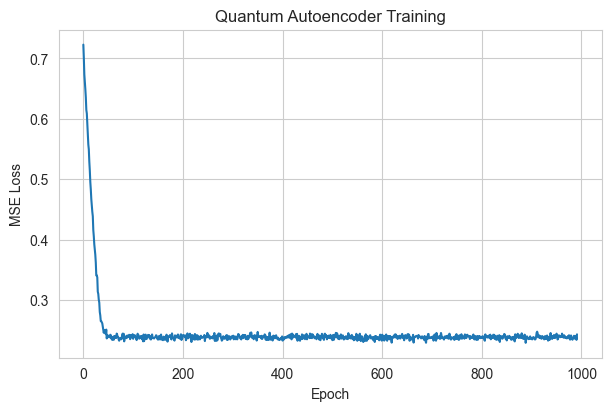

In [230]:
df_losses_quantum = pd.DataFrame({'Epoch': range(len(losses)), 'Loss': losses})
df_losses_quantum['Model'] = 'Quantum Circuit'

fig, axes = plt.subplots(figsize=(6, 4), layout='constrained',
                         # dpi=150
                         )
axes.plot(df_losses_quantum['Epoch'], df_losses_quantum['Loss'])
axes.set_xlabel("Epoch")
axes.set_ylabel("MSE Loss")
axes.set_title("Quantum Autoencoder Training")

## Compare original and reconstructed signal

In [214]:
X_quantum = df.to_numpy()

### Single row

Text(0.5, 1.0, 'Quantum Autoencoder Reconstruction')

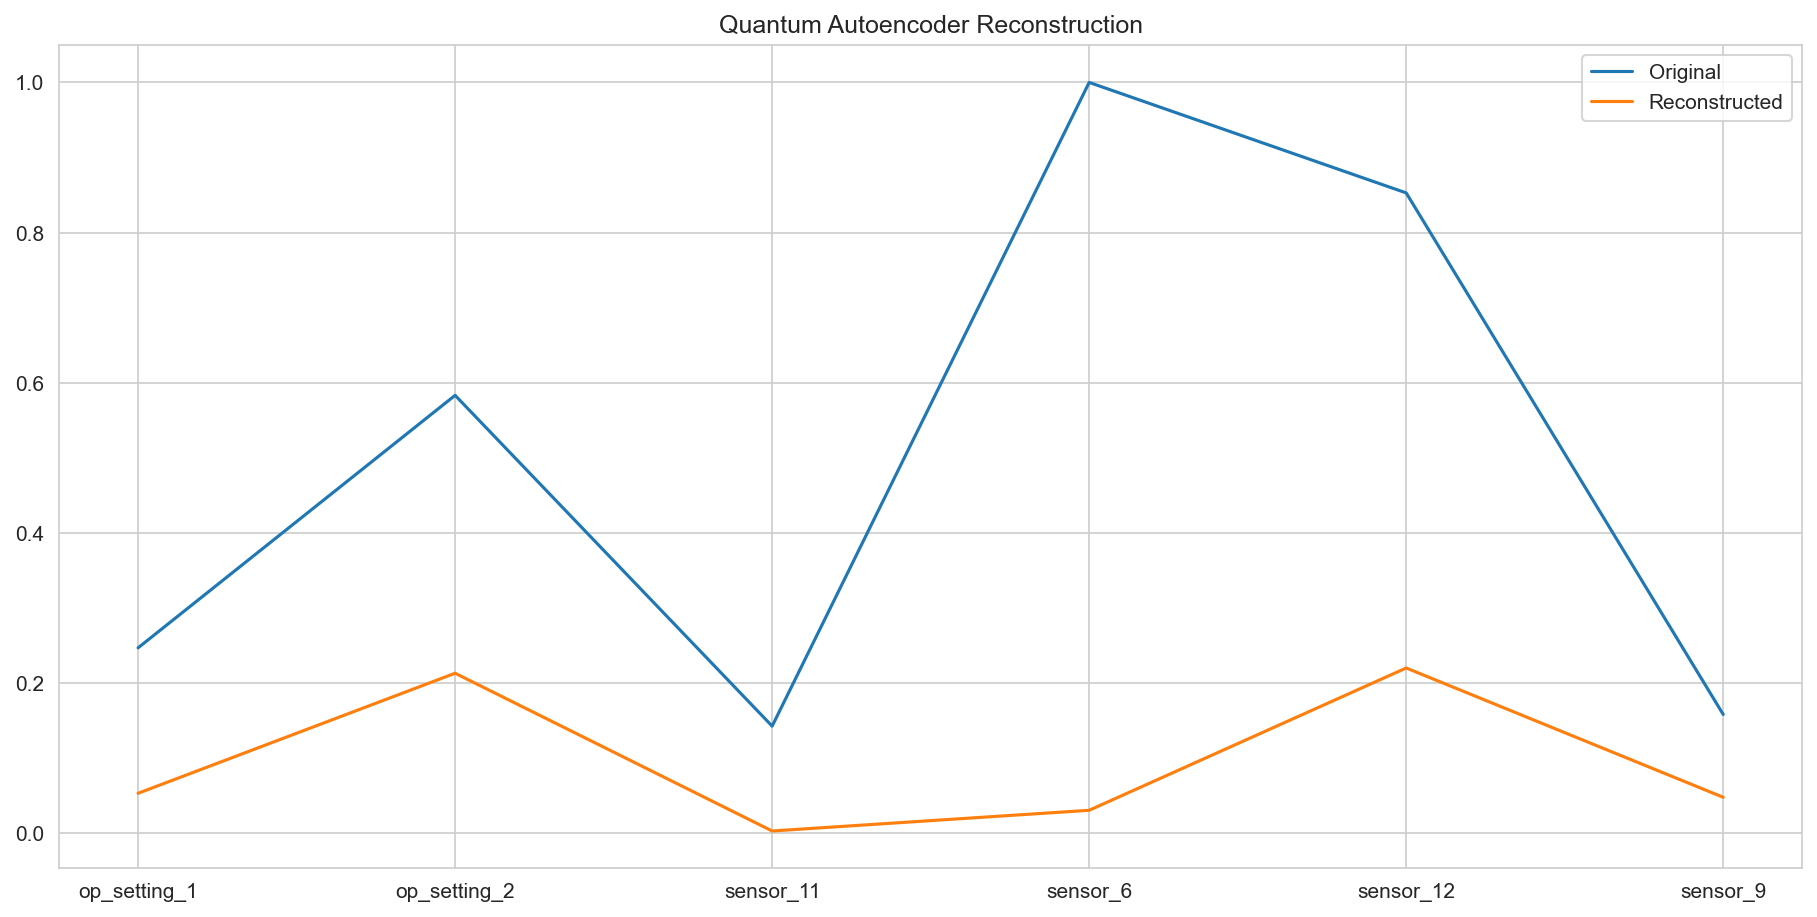

In [215]:
i = np.random.randint(0, len(X_quantum))
original = X_quantum[i]
reconstructed = quantum_circuit(original, weights)

fig, axes = plt.subplots(figsize=(12, 6), dpi=150, layout='constrained')
axes.plot(selected_features, original, label='Original')
axes.plot(selected_features, reconstructed, label='Reconstructed')
axes.legend()
axes.set_title("Quantum Autoencoder Reconstruction")

### All rows

In [ ]:
reconstructed = []
for row in tqdm(X_quantum):
    reconstructed.append(quantum_circuit(row, weights))

100%|██████████| 20631/20631 [00:51<00:00, 399.89it/s]


TypeError: can only concatenate list (not "int") to list

<Axes: xlabel='sensor', ylabel='delta'>

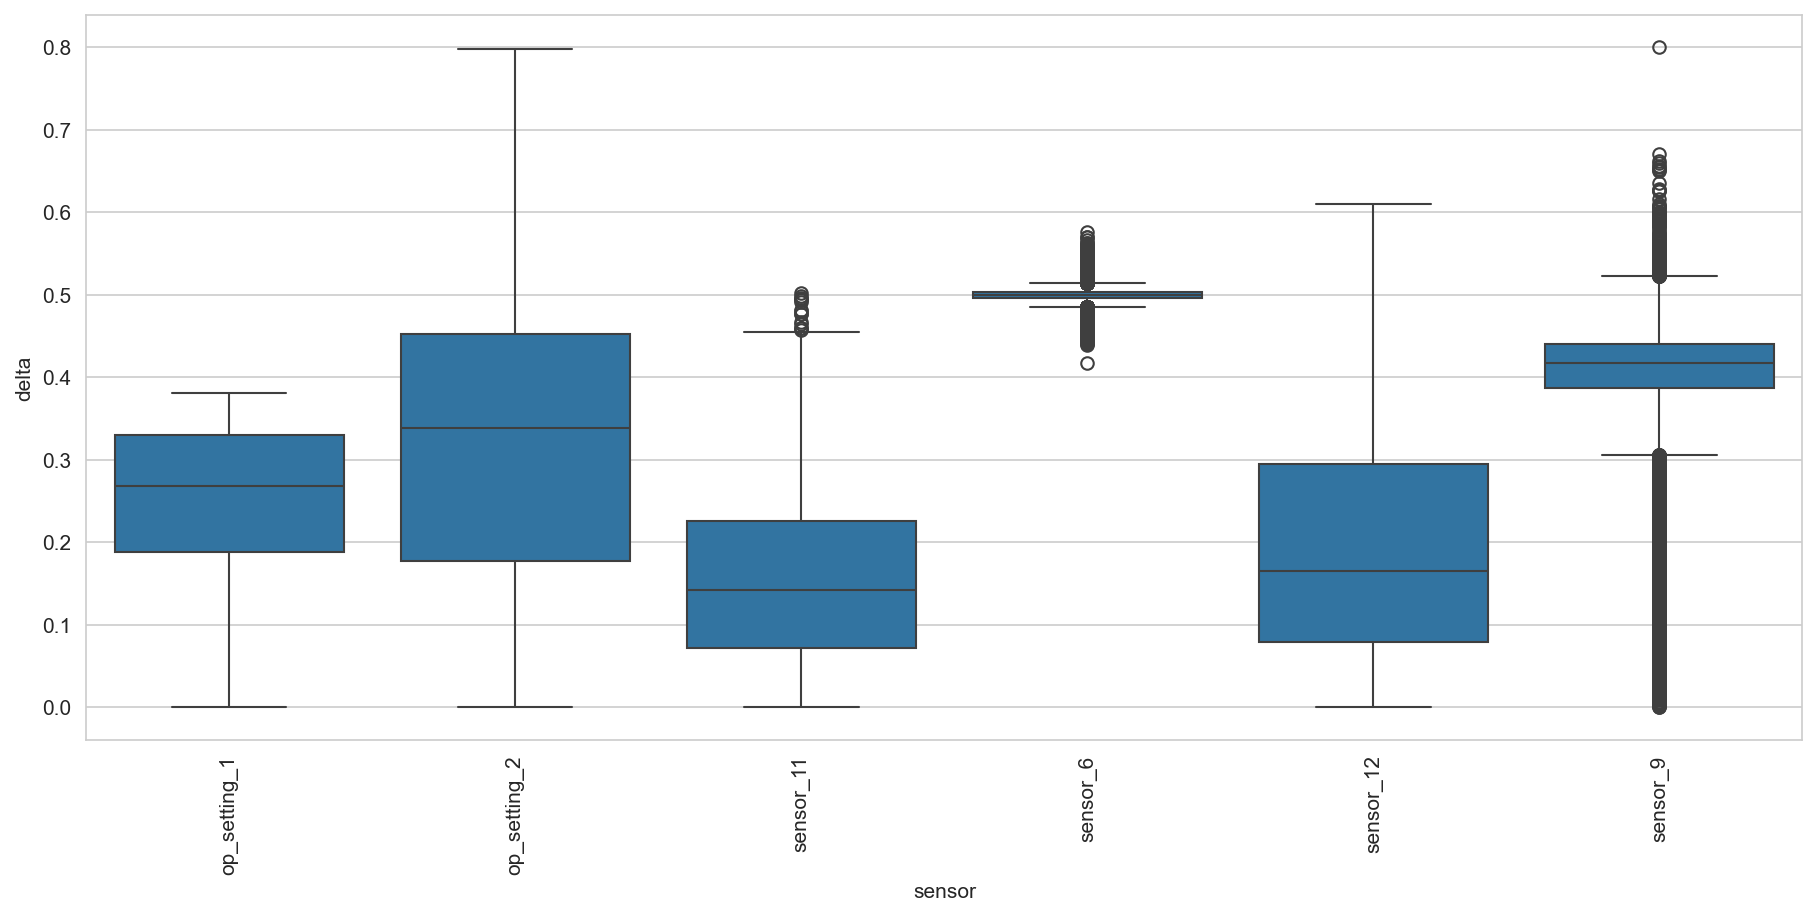

In [222]:
reconstructed = np.array(reconstructed)
delta_quantum = np.abs(X_quantum - 0.5*(reconstructed+1))
delta_quantum = pd.DataFrame(delta_quantum, columns=selected_features)
delta_quantum = pd.melt(delta_quantum, var_name='sensor', value_name='delta')

fig, axes = plt.subplots(figsize=(12, 6), dpi=150, layout='constrained')
axes.xaxis.set_tick_params(rotation=90)
sns.boxplot(x='sensor', y='delta', data=delta_quantum)

In [223]:
delta_quantum.describe()

,delta
count,1.237860e+05
mean,3.060031e-01
std,1.629921e-01
min,1.998401e-15
25%,1.674199e-01
50%,3.252270e-01
75%,4.511939e-01
max,7.996838e-01


## Errors

In [224]:
mse_q = (delta_quantum['delta']**2).mean()
mae_q = delta_quantum['delta'].mean()

print(f"Średni MSE: {mse_q:.6f}")
print(f"Średni MAE: {mae_q:.6f}")

Średni MSE: 0.120204
Średni MAE: 0.306003


# Comparison

## Training time comparison

Text(0.5, 1.0, 'Training Time Comparison')

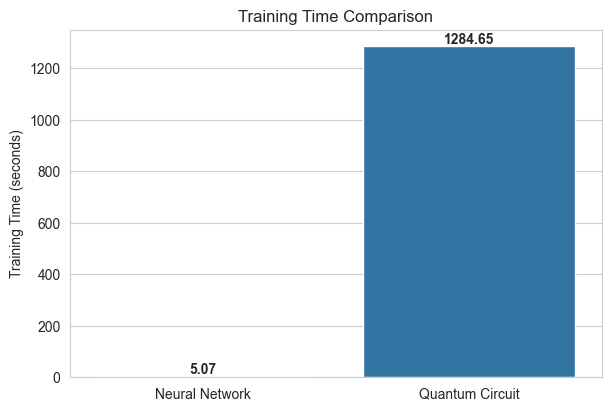

In [242]:
fig, axes = plt.subplots(figsize=(6, 4), layout='constrained')
sns.barplot(x=['Neural Network', 'Quantum Circuit'],
            y=[end_neural_time, end_q_time],
            ax=axes
            )

# Add data labels
for i, v in enumerate([end_neural_time, end_q_time]):
    axes.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
axes.set_ylabel("Training Time (seconds)")
axes.set_title("Training Time Comparison")

## Number of epochs until convergence

<Axes: xlabel='Epoch', ylabel='Loss'>

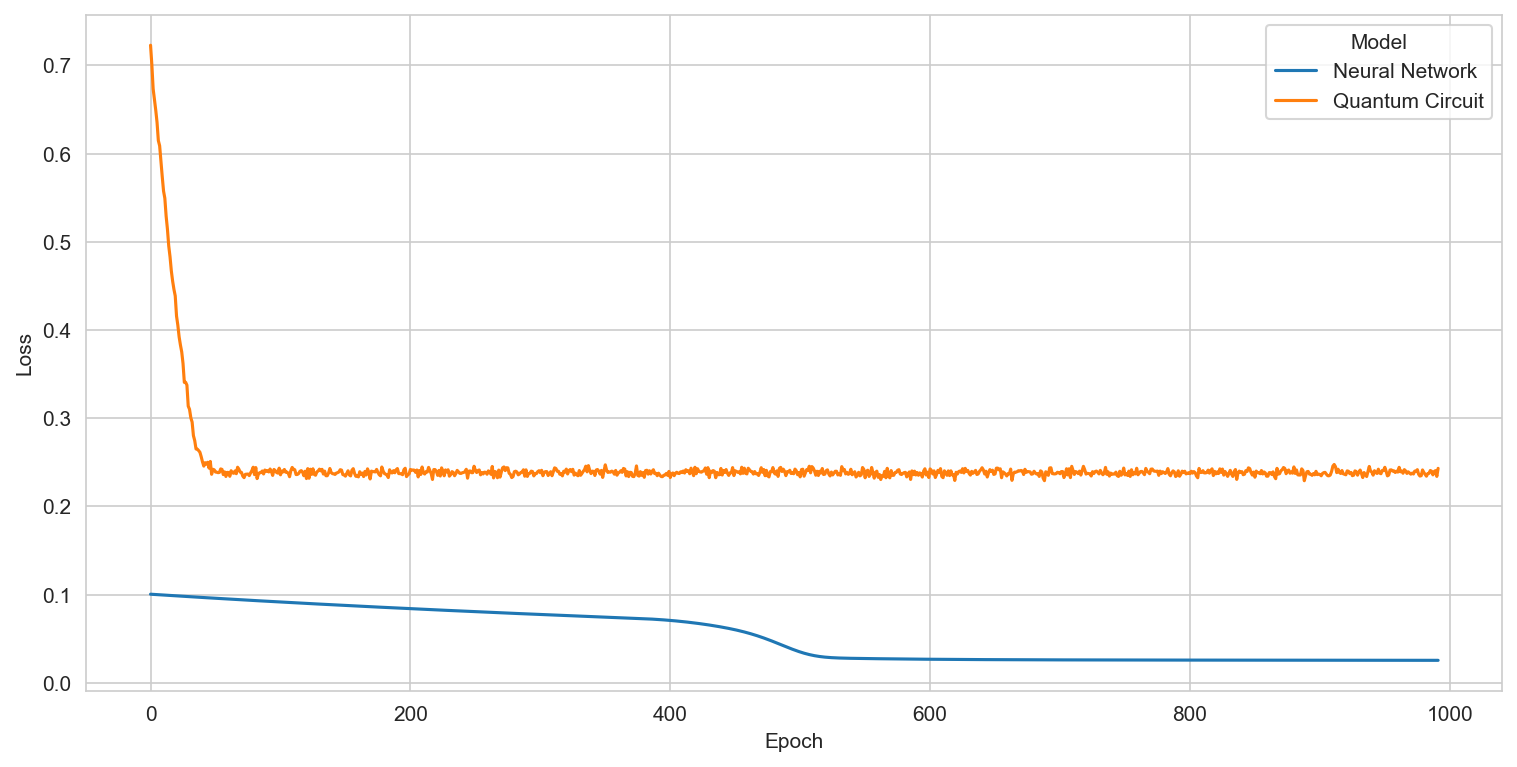

In [234]:
df_losses_compare = pd.concat([df_loss, df_losses_quantum],ignore_index=True)
fig, ax = plt.subplots(figsize=(10, 5), layout='constrained', dpi=150)
sns.lineplot(data=df_losses_compare, x='Epoch', y='Loss', hue='Model', ax=ax)

## Errors

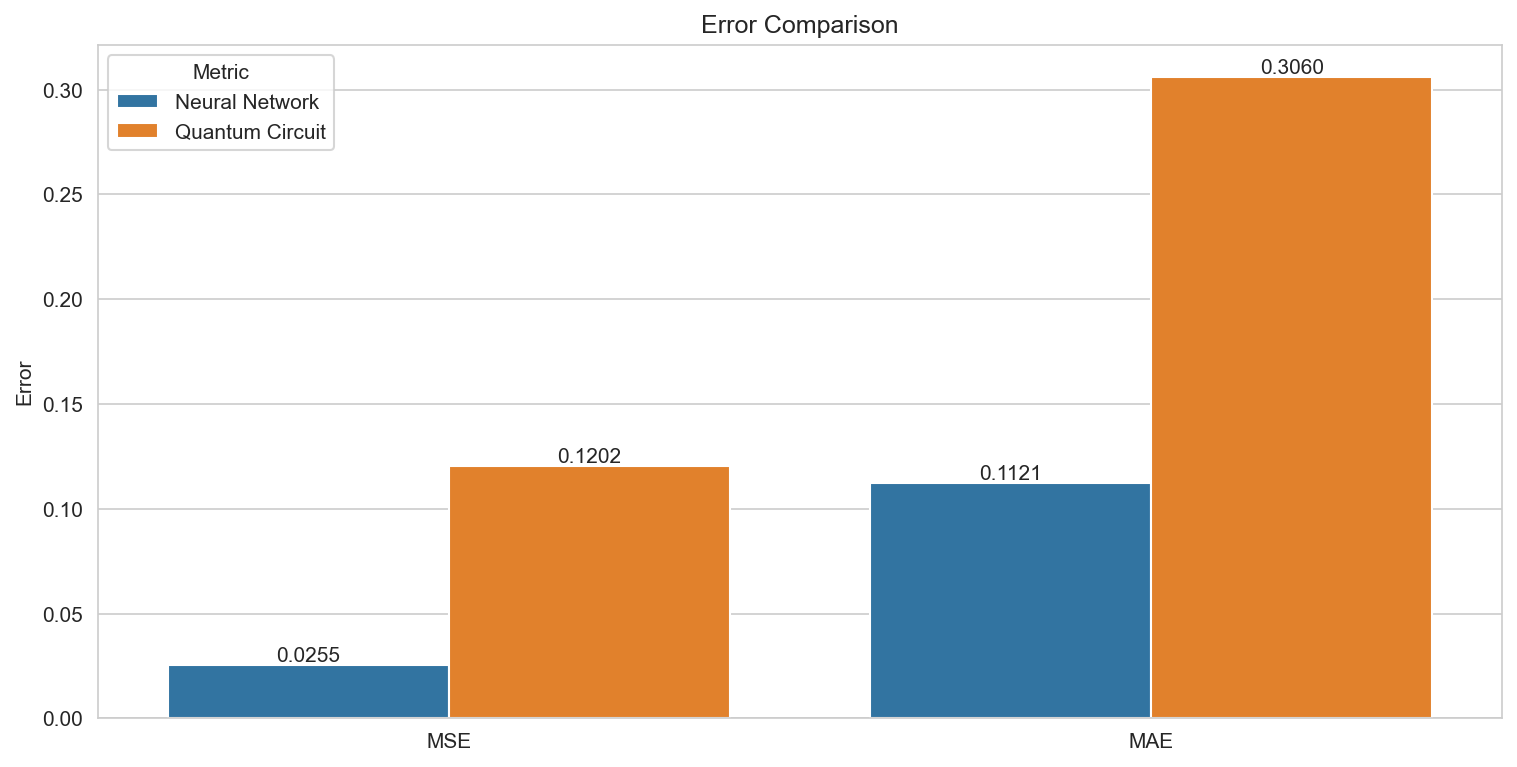

In [241]:
df_errors = pd.DataFrame({
    'Model': ['Neural Network', 'Quantum Circuit'],
    'MSE': [mse_neural, mse_q],
    'MAE': [mae_neural, mae_q]
})

df_plot = df_errors.melt(id_vars='Model',
                         value_vars=['MSE', 'MAE'],
                         var_name='Metric',
                         value_name='Error')

fig, ax = plt.subplots(figsize=(10, 5), layout='constrained', dpi=150)
sns.barplot(data=df_plot, x='Metric', y='Error', hue='Model', ax=ax)

ax.set_title('Error Comparison')
ax.set_xlabel('')
ax.set_ylabel('Error')
ax.legend(title='Metric')

for c in ax.containers:
    ax.bar_label(c, fmt='%.4f')
